In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

file_path = '/content/student_habits_performance.csv'
df = pd.read_csv(file_path)

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (1000, 16)


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


--- Missing Values ---
student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64


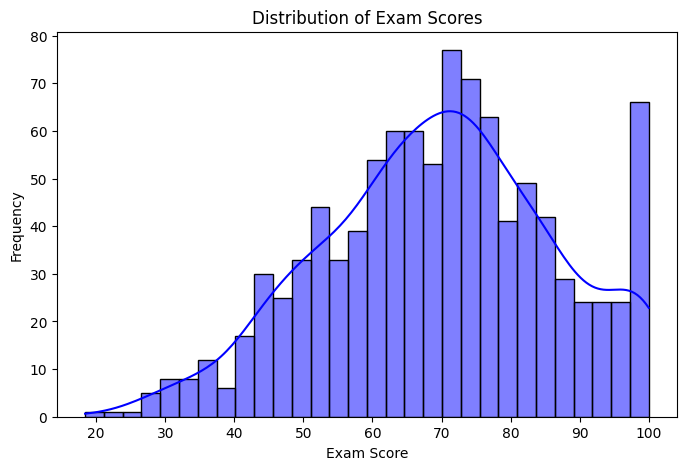

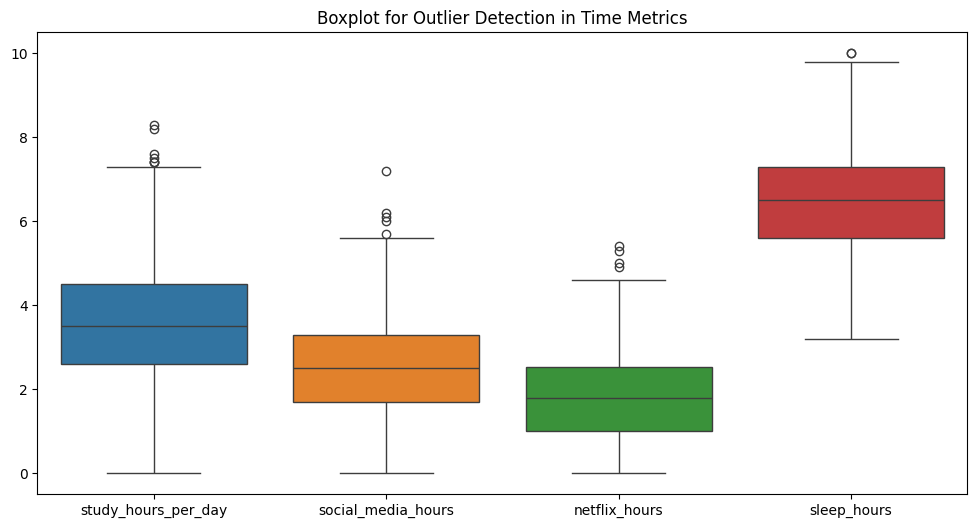

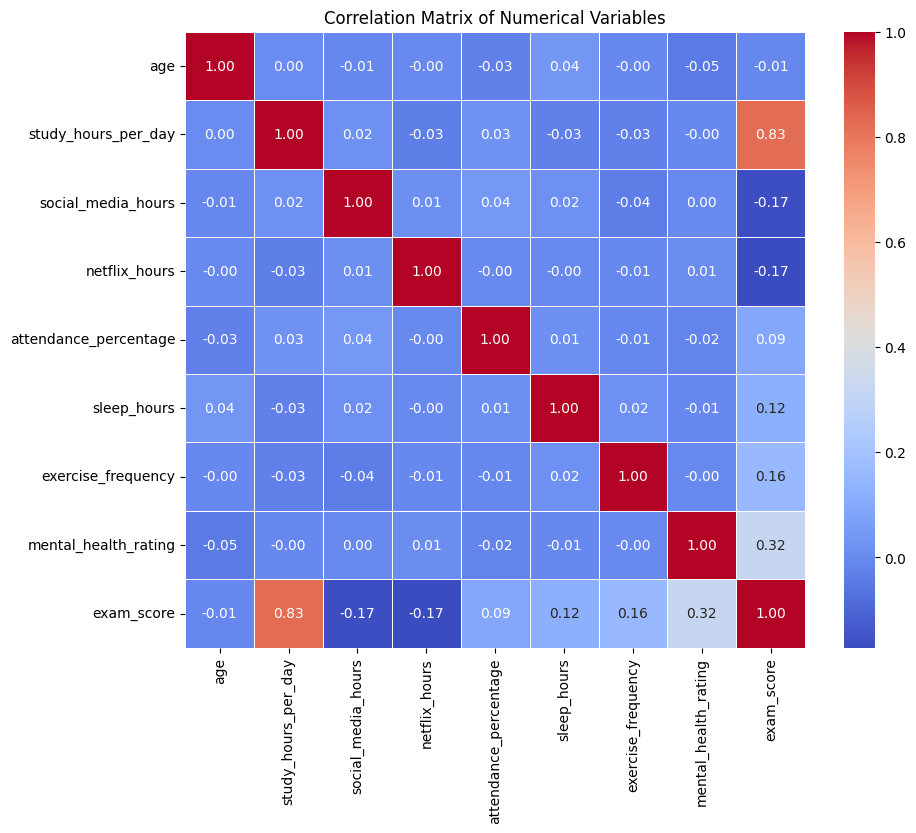

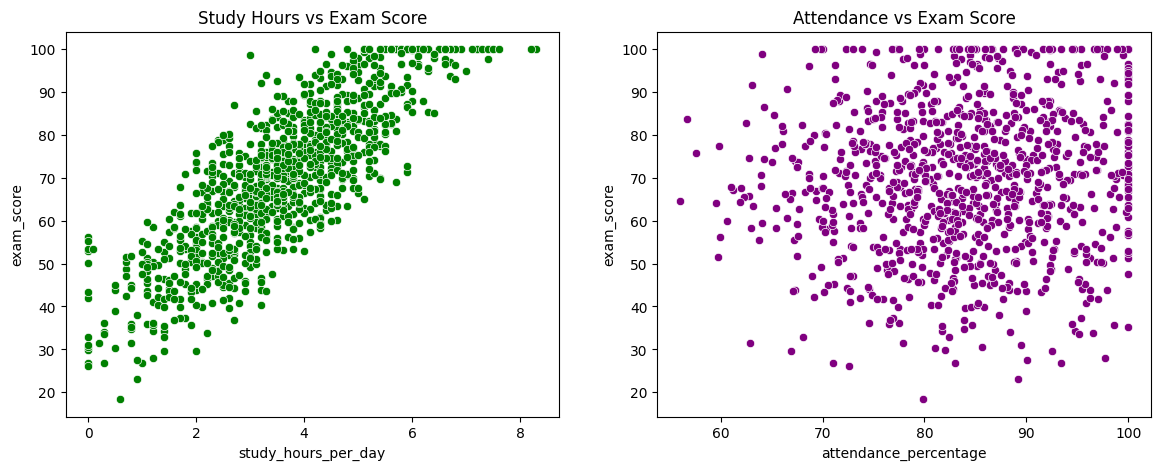

In [3]:
# 1. Check for Missing Values
print("--- Missing Values ---")
print(df.isnull().sum())

# 2. Identify Numerical and Categorical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

# 3. Target Variable Distribution (exam_score)
plt.figure(figsize=(8, 5))
sns.histplot(df['exam_score'], bins=30, kde=True, color='blue')
plt.title('Distribution of Exam Scores')
plt.xlabel('Exam Score')
plt.ylabel('Frequency')
plt.show()

# 4. Outlier Detection using Boxplots
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[['study_hours_per_day', 'social_media_hours', 'netflix_hours', 'sleep_hours']])
plt.title('Boxplot for Outlier Detection in Time Metrics')
plt.show()

# 5. Correlation Heatmap
plt.figure(figsize=(10, 8))
corr_matrix = df[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

# 6. Relationship between Study Hours, Attendance, and Exam Score
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df, x='study_hours_per_day', y='exam_score', ax=ax[0], color='green')
ax[0].set_title('Study Hours vs Exam Score')

sns.scatterplot(data=df, x='attendance_percentage', y='exam_score', ax=ax[1], color='purple')
ax[1].set_title('Attendance vs Exam Score')
plt.show()

In [4]:
# 1. Drop irrelevant columns
if 'student_id' in df.columns:
    df = df.drop('student_id', axis=1)

# 2. Impute missing values (Fill missing categorical data with the Mode)
mode_edu = df['parental_education_level'].mode()[0]
df['parental_education_level'] = df['parental_education_level'].fillna(mode_edu)

# 3. Encode Categorical Variables using One-Hot Encoding
cat_cols.remove('student_id') # Removed earlier
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# 4. Define Features (X) and Regression Target (y_reg)
X = df_encoded.drop('exam_score', axis=1)
y_reg = df_encoded['exam_score']

print("Preprocessing complete. X shape:", X.shape)

Preprocessing complete. X shape: (1000, 18)


In [5]:
# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)

# Feature Scaling (Standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and Train the Linear Regression Model
reg_model = LinearRegression()
reg_model.fit(X_train_scaled, y_train_reg)

# Generate Predictions
y_train_pred = reg_model.predict(X_train_scaled)
y_test_pred = reg_model.predict(X_test_scaled)

# Evaluate the Model
print("--- Linear Regression Performance ---")
print(f"Train R2 Score: {r2_score(y_train_reg, y_train_pred):.4f}")
print(f"Test R2 Score : {r2_score(y_test_reg, y_test_pred):.4f}")
print(f"Test RMSE     : {np.sqrt(mean_squared_error(y_test_reg, y_test_pred)):.4f}")
print(f"Test MAE      : {mean_absolute_error(y_test_reg, y_test_pred):.4f}")

--- Linear Regression Performance ---
Train R2 Score: 0.9021
Test R2 Score : 0.8965
Test RMSE     : 5.1510
Test MAE      : 4.1923


--- Classification Performance (Pass/Fail) ---
Training Accuracy: 0.96125
Testing Accuracy : 0.945

Classification Report (Test Data):
              precision    recall  f1-score   support

    Fail (0)       0.77      0.86      0.81        28
    Pass (1)       0.98      0.96      0.97       172

    accuracy                           0.94       200
   macro avg       0.88      0.91      0.89       200
weighted avg       0.95      0.94      0.95       200



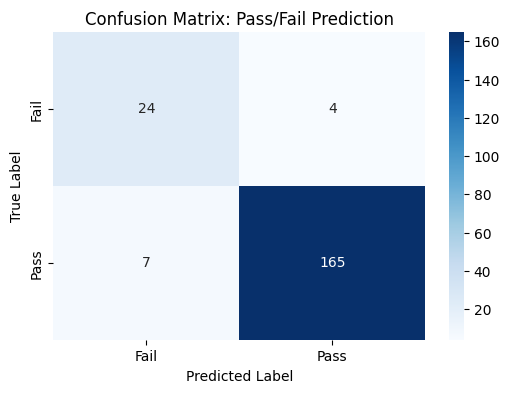

In [6]:
# 1. Create the Binary Target Variable
y_class = (df_encoded['exam_score'] >= 50).astype(int)

# 2. Train-Test Split for Classification
X_train, X_test, y_train_cls, y_test_cls = train_test_split(X, y_class, test_size=0.2, random_state=42)

# Use the same scaled features from Step 4
y_train_cls = (y_train_reg >= 50).astype(int)
y_test_cls = (y_test_reg >= 50).astype(int)

# 3. Train Logistic Regression Model
cls_model = LogisticRegression(random_state=42)
cls_model.fit(X_train_scaled, y_train_cls)

# 4. Generate Predictions
y_train_cls_pred = cls_model.predict(X_train_scaled)
y_test_cls_pred = cls_model.predict(X_test_scaled)

# 5. Evaluate the Classification Model
print("--- Classification Performance (Pass/Fail) ---")
print("Training Accuracy:", accuracy_score(y_train_cls, y_train_cls_pred))
print("Testing Accuracy :", accuracy_score(y_test_cls, y_test_cls_pred))

print("\nClassification Report (Test Data):")
print(classification_report(y_test_cls, y_test_cls_pred, target_names=['Fail (0)', 'Pass (1)']))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test_cls, y_test_cls_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fail', 'Pass'], yticklabels=['Fail', 'Pass'])
plt.title('Confusion Matrix: Pass/Fail Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Model Discussion: Overfitting vs. Underfitting

Based on the performance metrics of our models, we can evaluate how well they generalized to unseen data:

**1. Linear Regression Evaluation:**
*   Our Training R² is **0.9021** and our Testing R² is **0.8965**.
*   Because these two scores are incredibly close (only a 0.5% difference) and both are very high (explaining ~90% of the variance in exam scores), there are **no signs of overfitting or underfitting**. The model has successfully learned the true underlying patterns of the data rather than just memorizing the training set.

**2. Logistic Regression (Classification) Evaluation:**
*   Our Training Accuracy is **96.12%** and our Testing Accuracy is **94.50%**.
*   Once again, this small 1.6% gap indicates excellent generalization. The model is highly robust and performs consistently on unseen testing data.

---

##Final Business Insights & Conclusions

Based on our EDA and Machine Learning model results, here are 5 meaningful, data-driven insights regarding student performance:

1. **Academic Outcomes are Highly Predictable:** Our linear regression model achieved an R² of almost 0.90. This proves that exam scores are not random or purely based on "natural intelligence"; they are highly systematic and can be accurately predicted by tracking daily habits like study hours, sleep, and attendance.
2. **High Precision in Score Forecasting:** The Mean Absolute Error (MAE) of our regression model is **4.19**. This means that by simply knowing a student's lifestyle and study habits, we can predict their final exam score within roughly 4.2 points of their actual grade.
3. **Exceptional Early Intervention Potential:** In our classification model, the **Recall for failing students is 86%**. This means the model correctly successfully identified 86% of the students who were actually going to fail. A school could use this model mid-semester to flag these at-risk students and provide tutoring before the final exam.
4. **Handling Imbalanced Data:** Looking at the support metrics in the classification report, 172 students passed while only 28 failed. Despite this massive imbalance, our model still achieved an 81% F1-score for the failing class, proving the features (like low attendance or high Netflix hours) are strong enough indicators to detect failure even when it is rare.
5. **Holistic Success Metrics:** Because the model avoided overfitting and achieved 94.5% accuracy using a mix of academic (study hours, attendance) and lifestyle (sleep, social media, mental health) features, it mathematically proves that student success requires a balanced, holistic routine rather than just endless studying.